In [1]:
import os
import sys

# Get the path of the current file or notebook
current_path = os.path.abspath(
    __file__ if "__file__" in locals() else os.getcwd()
)

# Get the parent directory
parent_dir = os.path.dirname(current_path)
print(f"Parent directory: {parent_dir}")
# Add the parent directory to sys.path if it's not already there
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

import time

import matplotlib.pyplot as plt
from torch import Tensor, cat, device
from torch import empty as empty_tensor
from torch import float32 as torch_float32
from torch import float64 as torch_float64
from torch import get_num_threads, pi, tensor
from torch import zeros as zeros_tensor

from scanner_modeling._convex_hull._convex_hull_functions import (
    convex_hull_2d,
    sort_points_for_hull_2d,
)
from scanner_modeling._plot._mpl_plot_system import (
    plot_polygons_from_vertices_mpl,
    plot_scanner_from_vertices_2d_mpl,
)
from scanner_modeling._raytracer_2d._local_functions import (
    line_segments_t,
    rays_2d_batch,
    rays_edges_t_subdivisions,
    rays_intersection_lengths,
    sfov_properties,
    subdivision_grid_rectangle,
    subdivision_vertices_rectangle,
)
from scanner_modeling.geometry_2d import (
    fov_corners_vertices_2d,
    fov_tensor_dict,
    load_scanner_geometry_from_layout,
    load_scanner_layouts,
    polygon_edges_from_vertices_2d_batch,
    polygon_to_points_angular_span_2d_batch,
    reduced_scanner_objects_ids_local,
)

Parent directory: /home/fanghan/Work/spebt/packages/pymatcal


In [2]:
default_device = device("cuda:0")

scanner_layout_file_relative_path = (
    "../scanner_layouts/scanner_layouts_e1531c3444e51439add2f18f5714fc50.tensor"
)
# Get the dir and filename from the relative path
scanner_layout_dir = os.path.dirname(scanner_layout_file_relative_path)
scanner_layout_filename = os.path.basename(scanner_layout_file_relative_path)
layout_idx = 0
start_time = time.time()

scanner_layouts, layouts_md5 = load_scanner_layouts(
    scanner_layout_dir,
    scanner_layout_filename,
)


# mu_dict = {"plate": 3.5, "crystal": 0.475}  # mm^-1
mu_dict = tensor([3.5, 0.475], device=default_device)

fov_dict = fov_tensor_dict((512, 512), (128, 128), (0.0, 0.0), (8, 8))

crystal_n_subs = (9, 9)
# crystal_n_subs = (9, 9)
sfov_pxs_ids, sfov_pixels_batch, sfov_corners_batch = sfov_properties(fov_dict)
n_sfov = int(fov_dict["n subdivisions"].prod())
sfov_pxs_ids_1d = (
    sfov_pxs_ids[:, :, 0] * fov_dict["n pixels"][0] + sfov_pxs_ids[:, :, 1]
)

ppdf = empty_tensor(int(fov_dict["n pixels"].prod()), dtype=torch_float64)

print(f"Number of FOV Blocks:               {n_sfov}")
print(f"FOV Block Size:                     {sfov_pixels_batch.shape[1]}")
print(f"Number of Subdivisions per Crystal: {crystal_n_subs}")

print(
    f"PyTorch is set to use {get_num_threads()} threads for intra-op parallelism."
)

subdivision_grid = subdivision_grid_rectangle(crystal_n_subs)

(
    plate_objects_vertices,
    crystal_objects_vertices,
    plate_objects_edges,
    crystal_objects_edges,
) = load_scanner_geometry_from_layout(layout_idx, scanner_layouts)

crystal_idx = 234
mu_dict = mu_dict.to(default_device)
subdivision_grid = subdivision_grid.to(default_device)
# sfov_pxs_ids_1d = sfov_pxs_ids_1d.to("cpu")

sfov_pixels_batch = sfov_pixels_batch.to(default_device)
plate_objects_vertices = plate_objects_vertices.to(default_device)
crystal_objects_vertices = crystal_objects_vertices.to(default_device)
plate_objects_edges = plate_objects_edges.to(default_device)
crystal_objects_edges = crystal_objects_edges.to(default_device)
subdivision_grid = subdivision_grid.to(default_device)
sfov_corners_batch = sfov_corners_batch.to(default_device)
# for sfov_idx in range(n_sfov):
print(sfov_corners_batch[15])

Number of FOV Blocks:               64
FOV Block Size:                     4096
Number of Subdivisions per Crystal: (9, 9)
PyTorch is set to use 4 threads for intra-op parallelism.
tensor([[-48.,  48.],
        [-32.,  48.],
        [-32.,  64.],
        [-48.,  64.]], device='cuda:0')


In [3]:
# ppdf = zeros_tensor(
#     int(fov_dict["n pixels"].prod()), dtype=torch_float64, device=default_device
# )
ppdf_sfov_list = []
sfov_reduced_crystal_ids_list = []
sfov_reduced_plate_ids_list = []
sfov_hull_list = []
sub_crystals_vertices = subdivision_vertices_rectangle(
    crystal_objects_vertices[crystal_idx], subdivision_grid
)
for sfov_idx in range(n_sfov):
    print(f"Processing SFOV {sfov_idx + 1} of {n_sfov}...")
    local_hull = convex_hull_2d(
        sort_points_for_hull_2d(
            cat(
                (
                    sfov_corners_batch[sfov_idx],
                    crystal_objects_vertices[crystal_idx],
                ),
                dim=0,
            )
        )
    )
    sfov_hull_list.append(local_hull)
    reduced_plate_objects_ids, reduced_crystal_objects_ids = (
        reduced_scanner_objects_ids_local(
            local_hull,
            plate_objects_vertices,
            crystal_objects_vertices,
            plate_objects_edges,
            crystal_objects_edges,
            device=default_device,
        )
    )
    sfov_reduced_crystal_ids_list.append(reduced_crystal_objects_ids)
    sfov_reduced_plate_ids_list.append(reduced_plate_objects_ids)
    # reduced_plate_objects_edges_ids = (
    #     reduced_plate_objects_ids.repeat_interleave(4, dim=0).squeeze()
    # )
    # reduced_crystal_objects_edges_ids = (
    #     reduced_crystal_objects_ids.repeat_interleave(4, dim=0).squeeze()
    # )
    print(f"Reduced plate objects IDs: {reduced_plate_objects_ids.tolist()}")
    print(f"Reduced crystal IDs: {reduced_crystal_objects_ids.tolist()}")
    reduced_plate_edges = plate_objects_edges[reduced_plate_objects_ids]
    reduced_crystal_edges = crystal_objects_edges[
        reduced_crystal_objects_ids
    ]

    sub_crystals_edges = polygon_edges_from_vertices_2d_batch(
        sub_crystals_vertices
    )

    pa_batch = sfov_pixels_batch[sfov_idx]
    pb_batch = sub_crystals_vertices.mean(dim=1)

    rays = rays_2d_batch(pa_batch, pb_batch)
    rays_plates_transmission_t = line_segments_t(
        rays.view(-1, 2, 2), reduced_plate_edges.view(-1, 2, 2)
    )
   
    rays_crystal_transmission_t = line_segments_t(
        rays.view(-1, 2, 2), reduced_crystal_edges.view(-1, 2, 2)
    )
    print(f"Rays shape: {rays.shape}")
    print(f"Rays plates transmission t shape: {rays_plates_transmission_t.shape}")
    print(f"Rays crystal transmission t shape: {rays_crystal_transmission_t.shape}")
    rays_sub_crystal_t = rays_edges_t_subdivisions(rays, sub_crystals_edges)

    intersection_length_plates = rays_intersection_lengths(
        rays, rays_plates_transmission_t
    ).view(rays.shape[0], rays.shape[1], -1)
    intersection_length_crystals = rays_intersection_lengths(
        rays, rays_crystal_transmission_t
    ).view(rays.shape[0], rays.shape[1], -1)

    intersection_length_subdivisions = rays_intersection_lengths(
        rays, rays_sub_crystal_t
    ).view(rays.shape[0], rays.shape[1])

    subdivision_rads_span = polygon_to_points_angular_span_2d_batch(
        sub_crystals_vertices, pa_batch
    )

    sum_plate_exponent = (intersection_length_plates * mu_dict[0]).sum(dim=2)
    sum_crystal_exponent = (intersection_length_crystals * mu_dict[1]).sum(
        dim=2
    )
    subdivision_exponent = intersection_length_subdivisions * float(mu_dict[1])
    angular_term = subdivision_rads_span / (2 * pi)

    # ppdf[sfov_pxs_ids_1d[sfov_idx]] = (
    #     (-sum_plate_exponent - sum_crystal_exponent).exp()
    #     * (subdivision_exponent.exp() - 1)
    #     * angular_term
    # ).sum(dim=1)
    ppdf_sfov_list.append(
        (
            (-sum_plate_exponent - sum_crystal_exponent).exp()
            * (subdivision_exponent.exp() - 1)
            * angular_term
        ).sum(dim=1)
    )

Processing SFOV 1 of 64...
Reduced plate objects IDs: [57, 58]
Reduced crystal IDs: [152, 153, 168, 169, 185, 186, 201, 202, 218, 234]
Rays shape: torch.Size([4096, 81, 2, 2])
Rays plates transmission t shape: torch.Size([331776, 8])
Rays crystal transmission t shape: torch.Size([331776, 40])
Processing SFOV 2 of 64...
Reduced plate objects IDs: [58, 59]
Reduced crystal IDs: [152, 153, 168, 169, 185, 186, 201, 202, 218, 234]
Rays shape: torch.Size([4096, 81, 2, 2])
Rays plates transmission t shape: torch.Size([331776, 8])
Rays crystal transmission t shape: torch.Size([331776, 40])
Processing SFOV 3 of 64...
Reduced plate objects IDs: [58, 59]
Reduced crystal IDs: [153, 169, 185, 186, 201, 202, 218, 234]
Rays shape: torch.Size([4096, 81, 2, 2])
Rays plates transmission t shape: torch.Size([331776, 8])
Rays crystal transmission t shape: torch.Size([331776, 32])
Processing SFOV 4 of 64...
Reduced plate objects IDs: [59, 60]
Reduced crystal IDs: [153, 169, 185, 186, 201, 202, 218, 234]
Ray

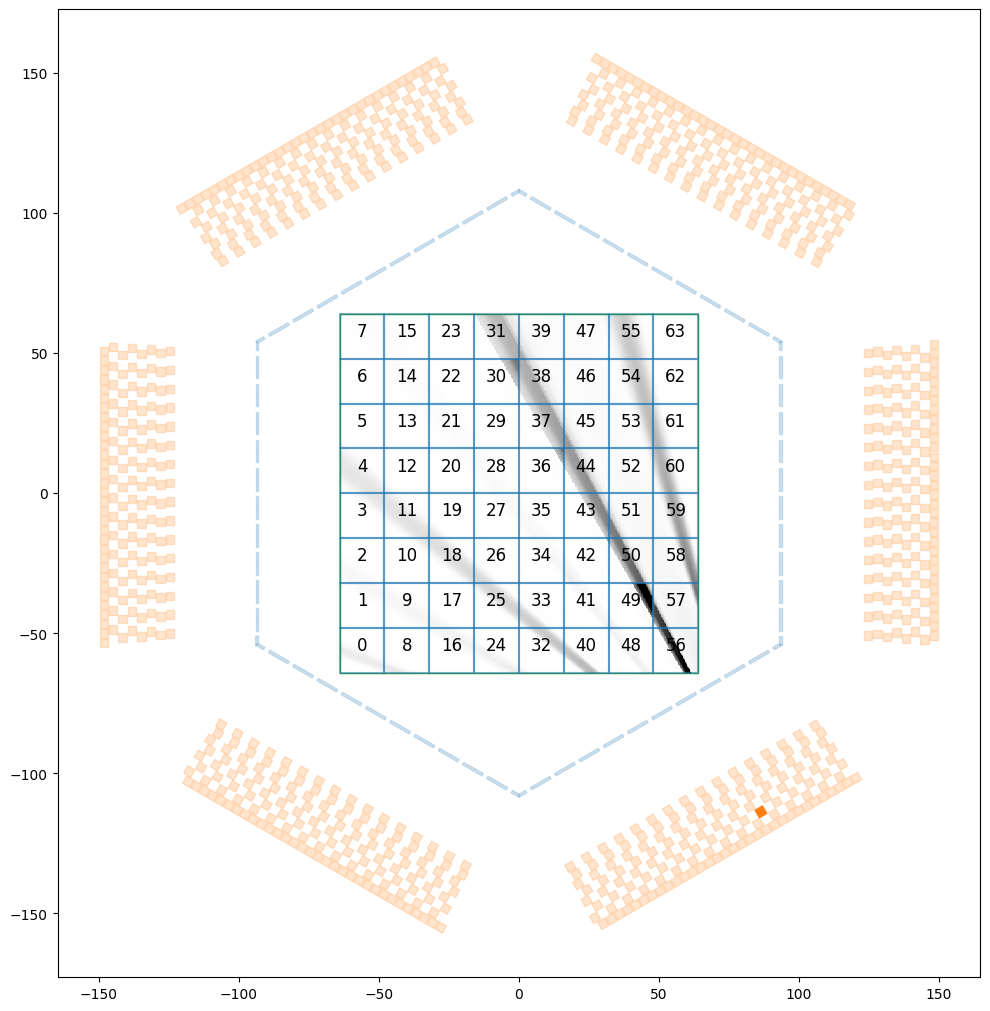

In [4]:


plt.close("all")
fig, ax = plt.subplots(figsize=(10, 10), layout="constrained")
for sfov_idx, ppdf_sfov in enumerate(ppdf_sfov_list):
    sfov_corners = sfov_corners_batch[sfov_idx].cpu().numpy()
    sfov_center = sfov_corners.mean(axis=0)
    sfov_extent = (
        sfov_corners[:, 0].min(),
        sfov_corners[:, 0].max(),
        sfov_corners[:, 1].min(),
        sfov_corners[:, 1].max(),
    )
    ax.imshow(
        ppdf_sfov.cpu()
        .view(
            fov_dict["n pixels"][0] // fov_dict["n subdivisions"][0],
            fov_dict["n pixels"][1] // fov_dict["n subdivisions"][1],
        )
        .T,
        origin="lower",
        extent=sfov_extent,
        cmap="gray_r",
        interpolation="none",
        vmin=0,
        vmax=1e-3,
    )
    ax.annotate(
        f"{sfov_idx}",
        sfov_center,
        textcoords="offset points",
        xytext=(0, 0),
        ha="center",
        fontsize=12,
        color="black",
    )

scanner_polycoll_dict = plot_scanner_from_vertices_2d_mpl(
    plate_objects_vertices, crystal_objects_vertices, ax, fov_dict, plate_alpha=0.2, crystal_alpha=0.2, fov_alpha=1
)
selected_crystal_polycoll = plot_polygons_from_vertices_mpl(
    crystal_objects_vertices[crystal_idx : crystal_idx + 1], ax, color="C1"
)

#Plot the SFOV frame
sfov_polycoll = plot_polygons_from_vertices_mpl(
    sfov_corners_batch, ax, ec="C0", fc="none", linewidth=1.5, alpha=0.5
)
# selected_sfov_idx = 49
# selected_sfov_polycoll = plot_polygons_from_vertices_mpl(
#     sfov_corners_batch[selected_sfov_idx : selected_sfov_idx + 1],
#     ax,
#     ec="none",
#     fc="C3",
#     alpha=0.2
# )
# selected_sfov_crystal_ids = sfov_reduced_crystal_ids_list[selected_sfov_idx]
# print(f"Selected SFOV {selected_sfov_idx} reduced crystal IDs: {selected_sfov_crystal_ids}")
# selected_sfov_hull = sfov_hull_list[selected_sfov_idx]
# selected_sfov_hull_polycoll = plot_polygons_from_vertices_mpl(
#     selected_sfov_hull.unsqueeze(0), ax, ec="C2", fc="none", linewidth=1.5, alpha=0.5
# )


# selected_sfov_reduced_crystals_polycoll = plot_polygons_from_vertices_mpl(
#     crystal_objects_vertices[selected_sfov_crystal_ids],
#     ax,
#     fc="C3",
#     ec="none",
#     alpha=1,
# )
# selected_sfov_reduced_plates_polycoll = plot_polygons_from_vertices_mpl(
#     plate_objects_vertices[sfov_reduced_plate_ids_list[selected_sfov_idx]],
#     ax,
#     fc="C3",
#     ec="none",
#     alpha=1,
# )

In [5]:
sfov_corners= sfov_corners_batch[15].cpu().numpy()
print(f"SFOV Corners: {sfov_corners[:,0].min()} {sfov_corners[:,0].max()}")
print(f"SFOV Corners: {sfov_corners[:,1].min()} {sfov_corners[:,1].max()}")

SFOV Corners: -48.0 -32.0
SFOV Corners: 48.0 64.0


In [6]:
# Processing SFOV 1 of 64...
# Reduced plate objects IDs: [57, 58]
# Reduced crystal IDs: [152, 153, 168, 169, 185, 186, 201, 202, 218, 234]
# Rays shape: torch.Size([256, 81, 2, 2])
# Rays plates transmission t shape: torch.Size([20736, 32])
# Rays crystal transmission t shape: torch.Size([20736, 160])

print(256*81, 10*4)

20736 40


In [7]:
reduced_crystal_objects_ids = tensor([152, 153, 168, 169, 185, 186, 201, 202, 218, 234])
# reduced_crystal_objects_edges_ids = (
#     reduced_crystal_objects_ids.repeat_interleave(4, dim=0).squeeze()
# )
print(f"Reduced plate objects IDs: {reduced_plate_objects_ids.tolist()}")
print(f"Reduced crystal IDs: {reduced_crystal_objects_ids}")
# print(f"reduced_crystal_objects_edges_ids: {reduced_crystal_objects_edges_ids.tolist()}")
print(f"Crystal objects edges shape: {crystal_objects_edges.shape}")
reduced_crystal_edges = crystal_objects_edges[
    reduced_crystal_objects_ids
]
print(f"Reduced crystal edges shape: {reduced_crystal_edges.shape}")

Reduced plate objects IDs: [63]
Reduced crystal IDs: tensor([152, 153, 168, 169, 185, 186, 201, 202, 218, 234])
Crystal objects edges shape: torch.Size([864, 4, 2, 2])
Reduced crystal edges shape: torch.Size([10, 4, 2, 2])
